# Loan Approval System

This notebook predicts loan approvals with Logistic Regression and Random Forest using the Kaggle dataset [`mytalkwithyou/bank-loan-approval-dataset`](https://www.kaggle.com/datasets/mytalkwithyou/bank-loan-approval-dataset).

The workflow is built to run reliably on CPU, with optional accelerator paths:

- **CUDA:** uses RAPIDS/cuML for Logistic Regression and Random Forest when `cuml` is available.
- **Apple Silicon / MLX:** uses MLX for an optional logistic regression experiment when `mlx` is installed.
- **Fallback:** scikit-learn models always run and are the primary comparable results.

In [17]:
from __future__ import annotations

import json
import os
import platform
import shutil
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd()
RAW_DATA = PROJECT_ROOT / "data" / "raw" / "loan_approval_dataset.csv"
MODEL_DIR = PROJECT_ROOT / "models"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
REPORT_DIR = PROJECT_ROOT / "reports"
for path in [RAW_DATA.parent, MODEL_DIR, FIG_DIR, REPORT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

## Hardware Detection

The notebook keeps acceleration optional. scikit-learn is the stable baseline; CUDA and MLX paths activate only when the right packages and hardware are present.

In [18]:
def detect_hardware() -> dict:
    info = {
        "python": platform.python_version(),
        "platform": platform.platform(),
        "machine": platform.machine(),
        "cuda_available": False,
        "torch_device": None,
        "cuml_available": False,
        "mlx_available": False,
    }
    try:
        import torch

        info["cuda_available"] = bool(torch.cuda.is_available())
        info["torch_device"] = torch.cuda.get_device_name(0) if info["cuda_available"] else "cpu"
    except Exception as exc:
        info["torch_device"] = f"torch unavailable: {exc.__class__.__name__}"

    try:
        import cuml  # noqa: F401

        info["cuml_available"] = True
    except Exception:
        info["cuml_available"] = False

    try:
        import mlx.core as mx  # noqa: F401

        info["mlx_available"] = True
    except Exception:
        info["mlx_available"] = False

    return info

hardware = detect_hardware()
hardware

{'python': '3.12.11',
 'platform': 'macOS-26.3-arm64-arm-64bit',
 'machine': 'arm64',
 'cuda_available': False,
 'torch_device': 'torch unavailable: ModuleNotFoundError',
 'cuml_available': False,
 'mlx_available': False}

## Dataset Download

KaggleHub can download public Kaggle datasets without putting code in the notebook that depends on a browser session. If the file is already present in `data/raw`, this cell leaves it alone.

In [19]:
def ensure_dataset() -> Path:
    if RAW_DATA.exists():
        return RAW_DATA

    try:
        import kagglehub

        dataset_path = Path(kagglehub.dataset_download("mytalkwithyou/bank-loan-approval-dataset"))
        csv_files = sorted(dataset_path.glob("*.csv"))
        if not csv_files:
            raise FileNotFoundError(f"No CSV found in downloaded dataset: {dataset_path}")
        shutil.copy2(csv_files[0], RAW_DATA)
        return RAW_DATA
    except Exception as exc:
        raise RuntimeError(
            "Dataset download failed. Add your Kaggle API token if needed, or place "
            f"loan_approval_dataset.csv at {RAW_DATA}. Original error: {exc}"
        ) from exc

csv_path = ensure_dataset()
print(csv_path)

/Users/hypno/project/aiml_pro/notebooks/data/raw/loan_approval_dataset.csv


## Load and Clean

The Kaggle CSV has several column names with leading spaces, so the first cleanup step normalizes names and target labels.

In [20]:
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

print(df.shape)
display(df.head())
display(df.info())

(70000, 23)


,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,person_gender_male,person_education_Bachelor,...,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_Yes,loan_status
0,22.0,71948.0,0,35000.0,16.02,0.49,3.0,561,0,0,...,0,0,1,0,0,0,1,0,0,1
1,21.0,12282.0,0,1000.0,11.14,0.08,2.0,504,0,0,...,0,1,0,1,0,0,0,0,1,0
2,25.0,12438.0,3,5500.0,12.87,0.44,3.0,635,0,0,...,0,0,0,0,0,1,0,0,0,1
3,23.0,79753.0,0,35000.0,15.23,0.44,2.0,675,0,1,...,0,0,1,0,0,1,0,0,0,1
4,24.0,66135.0,1,35000.0,14.27,0.53,4.0,586,1,0,...,0,0,1,0,0,1,0,0,0,1


<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 23 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   person_age                          70000 non-null  float64
 1   person_income                       70000 non-null  float64
 2   person_emp_exp                      70000 non-null  int64  
 3   loan_amnt                           70000 non-null  float64
 4   loan_int_rate                       70000 non-null  float64
 5   loan_percent_income                 70000 non-null  float64
 6   cb_person_cred_hist_length          70000 non-null  float64
 7   credit_score                        70000 non-null  int64  
 8   person_gender_male                  70000 non-null  int64  
 9   person_education_Bachelor           70000 non-null  int64  
 10  person_education_Doctorate          70000 non-null  int64  
 11  person_education_High School        70000 non-null  

None

In [21]:
target_col = "loan_status"
id_cols = [col for col in ["loan_id", "id"] if col in df.columns]

model_df = df.copy()
if pd.api.types.is_numeric_dtype(model_df[target_col]):
    model_df["approved"] = model_df[target_col].astype(int)
else:
    normalized_target = model_df[target_col].astype(str).str.strip().str.lower()
    model_df["approved"] = normalized_target.map({"approved": 1, "approve": 1, "yes": 1, "y": 1, "1": 1, "rejected": 0, "reject": 0, "no": 0, "n": 0, "0": 0})
    if model_df["approved"].isna().any():
        raise ValueError(f"Unrecognized target labels: {sorted(model_df[target_col].dropna().unique())}")
    model_df["approved"] = model_df["approved"].astype(int)

# Dataset-aware feature engineering. These derived ratios are created only when the needed columns exist.
if {"loan_amount", "income_annum"}.issubset(model_df.columns):
    model_df["loan_to_income_ratio"] = model_df["loan_amount"] / model_df["income_annum"].replace(0, np.nan)
elif {"loan_amnt", "person_income"}.issubset(model_df.columns):
    model_df["loan_to_income_ratio"] = model_df["loan_amnt"] / model_df["person_income"].replace(0, np.nan)

asset_columns = [
    "residential_assets_value",
    "commercial_assets_value",
    "luxury_assets_value",
    "bank_asset_value",
]
if set(asset_columns).issubset(model_df.columns):
    model_df["total_assets_value"] = model_df[asset_columns].sum(axis=1)
    loan_col = "loan_amount" if "loan_amount" in model_df.columns else "loan_amnt" if "loan_amnt" in model_df.columns else None
    if loan_col:
        model_df["asset_to_loan_ratio"] = model_df["total_assets_value"] / model_df[loan_col].replace(0, np.nan)

if {"income_annum", "no_of_dependents"}.issubset(model_df.columns):
    model_df["income_per_dependent"] = model_df["income_annum"] / (model_df["no_of_dependents"] + 1)

X = model_df.drop(columns=id_cols + [target_col, "approved"])
y = model_df["approved"]

print(y.value_counts(normalize=True).rename("class_share"))
display(X.describe(include="all").T)

approved
1    0.5
0    0.5
Name: class_share, dtype: float64


,count,mean,std,min,25%,50%,75%,max
person_age,70000.0,27.673129,5.691924,20.000000,24.000000,26.000000,30.000000,1.440000e+02
person_income,70000.0,72979.482571,70564.317723,8000.000000,41755.000000,61029.500000,87573.000000,7.200766e+06
person_emp_exp,70000.0,5.161043,5.676875,0.000000,1.000000,4.000000,7.000000,1.250000e+02
loan_amnt,70000.0,10020.783871,6623.701599,500.000000,5000.000000,8457.500000,14000.000000,3.500000e+04
loan_int_rate,70000.0,11.673156,3.005940,5.420000,9.750000,11.490000,13.861052,2.000000e+01
loan_percent_income,70000.0,0.162010,0.099094,0.000000,0.080000,0.140000,0.230000,6.600000e-01
cb_person_cred_hist_length,70000.0,5.826657,3.687981,2.000000,3.000000,4.000000,8.000000,3.000000e+01
credit_score,70000.0,632.424429,47.340891,390.000000,603.000000,638.000000,667.000000,8.500000e+02
person_gender_male,70000.0,0.463200,0.498647,0.000000,0.000000,0.000000,1.000000,1.000000e+00
person_education_Bachelor,70000.0,0.225586,0.417970,0.000000,0.000000,0.000000,0.000000,1.000000e+00


## Train/Test Split and Preprocessing

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

try:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", one_hot)]), categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

print(f"Train rows: {len(X_train):,}; test rows: {len(X_test):,}")
print(f"Numeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")

Train rows: 56,000; test rows: 14,000
Numeric features: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'person_gender_male', 'person_education_Bachelor', 'person_education_Doctorate', 'person_education_High School', 'person_education_Master', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'previous_loan_defaults_on_file_Yes', 'loan_to_income_ratio']
Categorical features: []


## Baseline Models: Logistic Regression and Random Forest

Both models use stratified cross-validation. Random Forest uses all available CPU cores through `n_jobs=-1`, which is the best portable path on macOS and non-RAPIDS environments.

In [23]:
def evaluate_model(name: str, model, X_eval, y_eval) -> dict:
    y_pred = model.predict(X_eval)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_eval)[:, 1]
    else:
        y_score = y_pred
    return {
        "model": name,
        "accuracy": accuracy_score(y_eval, y_pred),
        "precision": precision_score(y_eval, y_pred),
        "recall": recall_score(y_eval, y_pred),
        "f1": f1_score(y_eval, y_pred),
        "roc_auc": roc_auc_score(y_eval, y_score),
    }

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

logistic_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE)),
])

rf_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced_subsample",
        n_jobs=-1,
    )),
])

searches = {
    "Logistic Regression": GridSearchCV(
        logistic_pipeline,
        param_grid={
            "model__C": [0.3, 1.0, 3.0],
            "model__solver": ["lbfgs"],
        },
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
    ),
    "Random Forest": GridSearchCV(
        rf_pipeline,
        param_grid={
            "model__n_estimators": [200],
            "model__max_depth": [None, 14],
            "model__min_samples_leaf": [1, 4],
        },
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
    ),
}

fit_times = {}
for name, search in searches.items():
    start = time.perf_counter()
    search.fit(X_train, y_train)
    fit_times[name] = time.perf_counter() - start
    print(f"{name}: best CV ROC-AUC={search.best_score_:.4f}, params={search.best_params_}, fit_time={fit_times[name]:.2f}s")

Logistic Regression: best CV ROC-AUC=0.9745, params={'model__C': 3.0, 'model__solver': 'lbfgs'}, fit_time=4.02s
Random Forest: best CV ROC-AUC=0.9893, params={'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}, fit_time=19.93s


In [24]:
results = []
best_models = {name: search.best_estimator_ for name, search in searches.items()}
for name, model in best_models.items():
    row = evaluate_model(name, model, X_test, y_test)
    row["fit_seconds"] = fit_times[name]
    results.append(row)

metrics_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
display(metrics_df)
metrics_df.to_csv(REPORT_DIR / "metrics.csv", index=False)

for name, model in best_models.items():
    print("\n" + name)
    print(classification_report(y_test, model.predict(X_test), target_names=["Rejected", "Approved"]))

,model,accuracy,precision,recall,f1,roc_auc,fit_seconds
1,Random Forest,0.947500,0.944768,0.950571,0.947661,0.990924,19.934414
0,Logistic Regression,0.916429,0.903293,0.932714,0.917768,0.976942,4.016059



Logistic Regression
              precision    recall  f1-score   support

    Rejected       0.93      0.90      0.92      7000
    Approved       0.90      0.93      0.92      7000

    accuracy                           0.92     14000
   macro avg       0.92      0.92      0.92     14000
weighted avg       0.92      0.92      0.92     14000


Random Forest
              precision    recall  f1-score   support

    Rejected       0.95      0.94      0.95      7000
    Approved       0.94      0.95      0.95      7000

    accuracy                           0.95     14000
   macro avg       0.95      0.95      0.95     14000
weighted avg       0.95      0.95      0.95     14000



## Optional CUDA Path

This cell trains cuML models only when RAPIDS/cuML is available. That is the practical CUDA route for Logistic Regression and Random Forest. It is skipped on this Mac unless a compatible CUDA environment is present.

In [25]:
def to_dense_float32(matrix):
    if hasattr(matrix, "toarray"):
        matrix = matrix.toarray()
    return np.asarray(matrix, dtype=np.float32)

cuda_results = []
if hardware["cuml_available"]:
    from cuml.ensemble import RandomForestClassifier as CuMLRandomForestClassifier
    from cuml.linear_model import LogisticRegression as CuMLLogisticRegression

    cuda_preprocessor = preprocessor.fit(X_train, y_train)
    X_train_cuda = to_dense_float32(cuda_preprocessor.transform(X_train))
    X_test_cuda = to_dense_float32(cuda_preprocessor.transform(X_test))
    y_train_cuda = y_train.to_numpy(dtype=np.int32)

    cuda_models = {
        "CUDA cuML Logistic Regression": CuMLLogisticRegression(max_iter=3000),
        "CUDA cuML Random Forest": CuMLRandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE),
    }
    for name, model in cuda_models.items():
        start = time.perf_counter()
        model.fit(X_train_cuda, y_train_cuda)
        fit_seconds = time.perf_counter() - start
        y_pred = np.asarray(model.predict(X_test_cuda)).astype(int)
        if hasattr(model, "predict_proba"):
            y_score = np.asarray(model.predict_proba(X_test_cuda))[:, 1]
        else:
            y_score = y_pred
        cuda_results.append({
            "model": name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred),
            "recall": recall_score(y_test, y_pred),
            "f1": f1_score(y_test, y_pred),
            "roc_auc": roc_auc_score(y_test, y_score),
            "fit_seconds": fit_seconds,
        })
else:
    print("cuML not available; skipping CUDA models.")

pd.DataFrame(cuda_results)

cuML not available; skipping CUDA models.


""


## Optional MLX Logistic Regression

MLX is excellent for dense tensor workloads on Apple Silicon. Random Forest is not a natural MLX workload, so the MLX path below is limited to Logistic Regression and the Random Forest stays on the optimized scikit-learn CPU implementation.

In [26]:
def train_mlx_logistic_regression(X_train_np, y_train_np, X_test_np, epochs=900, lr=0.08, l2=1e-4):
    import mlx.core as mx

    X_mx = mx.array(X_train_np, dtype=mx.float32)
    y_mx = mx.array(y_train_np.reshape(-1, 1), dtype=mx.float32)
    X_test_mx = mx.array(X_test_np, dtype=mx.float32)

    n_features = X_train_np.shape[1]
    weights = mx.zeros((n_features, 1), dtype=mx.float32)
    bias = mx.zeros((1,), dtype=mx.float32)

    for _ in range(epochs):
        logits = X_mx @ weights + bias
        probs = 1 / (1 + mx.exp(-logits))
        grad_w = (X_mx.T @ (probs - y_mx)) / X_mx.shape[0] + l2 * weights
        grad_b = mx.mean(probs - y_mx)
        weights = weights - lr * grad_w
        bias = bias - lr * grad_b
        mx.eval(weights, bias)

    test_probs = 1 / (1 + mx.exp(-(X_test_mx @ weights + bias)))
    return np.array(test_probs).reshape(-1)

mlx_result = None
if hardware["mlx_available"]:
    mlx_preprocessor = preprocessor.fit(X_train, y_train)
    X_train_mlx = to_dense_float32(mlx_preprocessor.transform(X_train))
    X_test_mlx = to_dense_float32(mlx_preprocessor.transform(X_test))
    start = time.perf_counter()
    mlx_scores = train_mlx_logistic_regression(
        X_train_mlx,
        y_train.to_numpy(dtype=np.float32),
        X_test_mlx,
    )
    fit_seconds = time.perf_counter() - start
    mlx_pred = (mlx_scores >= 0.5).astype(int)
    mlx_result = {
        "model": "MLX Logistic Regression",
        "accuracy": accuracy_score(y_test, mlx_pred),
        "precision": precision_score(y_test, mlx_pred),
        "recall": recall_score(y_test, mlx_pred),
        "f1": f1_score(y_test, mlx_pred),
        "roc_auc": roc_auc_score(y_test, mlx_scores),
        "fit_seconds": fit_seconds,
    }
    display(pd.DataFrame([mlx_result]))
else:
    print("MLX not installed; skipping MLX logistic regression. Run `uv sync --extra mlx` on Apple Silicon to enable it.")

MLX not installed; skipping MLX logistic regression. Run `uv sync --extra mlx` on Apple Silicon to enable it.


## Visual Evaluation

In [27]:
comparison_df = metrics_df.copy()
if cuda_results:
    comparison_df = pd.concat([comparison_df, pd.DataFrame(cuda_results)], ignore_index=True)
if mlx_result:
    comparison_df = pd.concat([comparison_df, pd.DataFrame([mlx_result])], ignore_index=True)
comparison_df = comparison_df.sort_values("roc_auc", ascending=False)
display(comparison_df)
comparison_df.to_csv(REPORT_DIR / "metrics_all.csv", index=False)

best_name = comparison_df.iloc[0]["model"]
best_sklearn_name = metrics_df.iloc[0]["model"]
best_model = best_models[best_sklearn_name]
print(f"Best sklearn model: {best_sklearn_name}")
print(f"Best overall measured model: {best_name}")

,model,accuracy,precision,recall,f1,roc_auc,fit_seconds
1,Random Forest,0.947500,0.944768,0.950571,0.947661,0.990924,19.934414
0,Logistic Regression,0.916429,0.903293,0.932714,0.917768,0.976942,4.016059


Best sklearn model: Random Forest
Best overall measured model: Random Forest


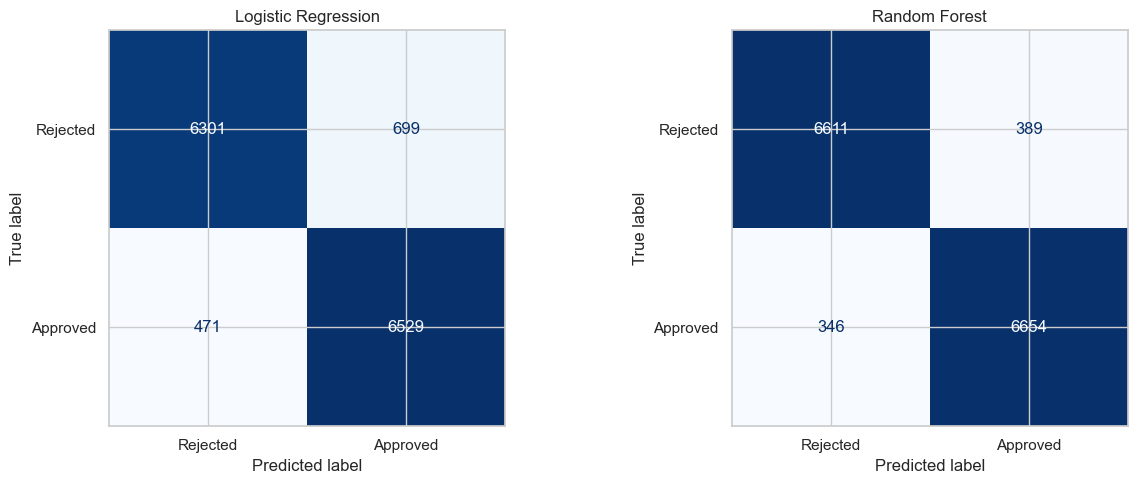

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, model) in zip(axes, best_models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        display_labels=["Rejected", "Approved"],
        cmap="Blues",
        ax=ax,
        colorbar=False,
    )
    ax.set_title(name)
plt.tight_layout()
fig.savefig(FIG_DIR / "confusion_matrices.png", dpi=160, bbox_inches="tight")
plt.show()

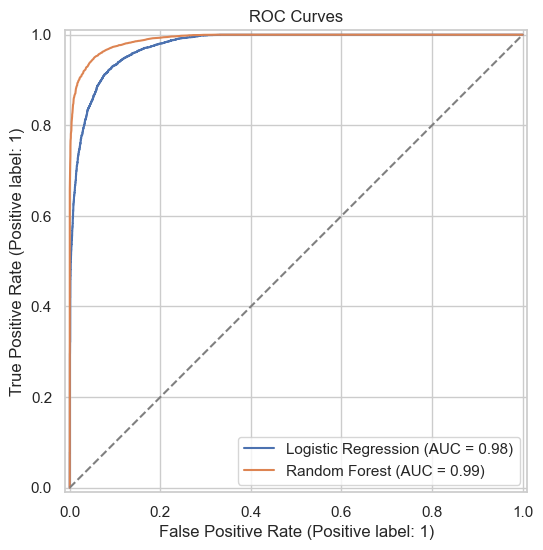

In [29]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, model in best_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=ax)
ax.plot([0, 1], [0, 1], "--", color="0.5")
ax.set_title("ROC Curves")
fig.savefig(FIG_DIR / "roc_curves.png", dpi=160, bbox_inches="tight")
plt.show()

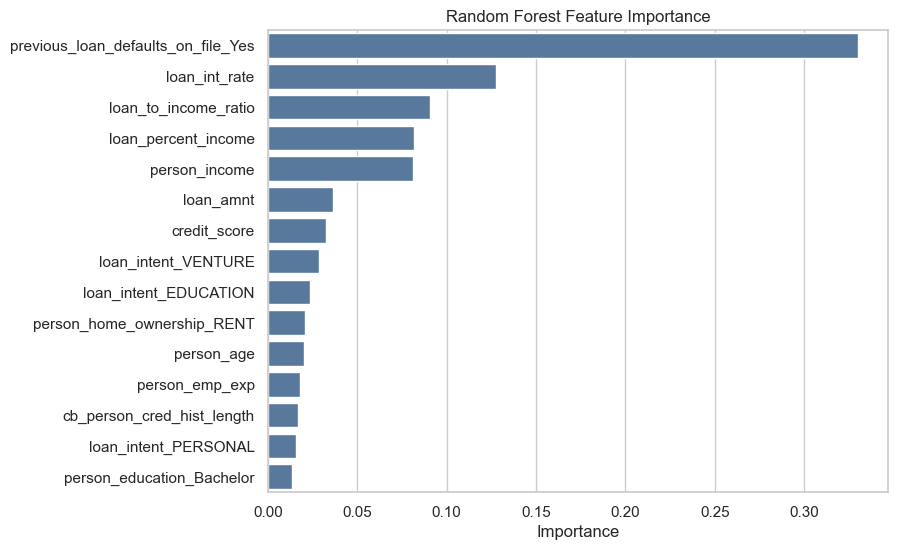

,feature,importance
21,previous_loan_defaults_on_file_Yes,0.330299
4,loan_int_rate,0.127900
22,loan_to_income_ratio,0.090962
5,loan_percent_income,0.081822
1,person_income,0.081152
3,loan_amnt,0.036240
7,credit_score,0.032693
20,loan_intent_VENTURE,0.028467
16,loan_intent_EDUCATION,0.023735
15,person_home_ownership_RENT,0.020783


In [30]:
rf_model = best_models["Random Forest"]
feature_names = rf_model.named_steps["preprocess"].get_feature_names_out()
importances = rf_model.named_steps["model"].feature_importances_
importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=importance_df, x="importance", y="feature", ax=ax, color="#4C78A8")
ax.set_title("Random Forest Feature Importance")
ax.set_xlabel("Importance")
ax.set_ylabel("")
fig.savefig(FIG_DIR / "random_forest_feature_importance.png", dpi=160, bbox_inches="tight")
plt.show()
display(importance_df)

## Save Models and Prediction Helper

In [31]:
model_bundle = {
    "models": best_models,
    "metrics": metrics_df.to_dict(orient="records"),
    "features": X.columns.tolist(),
    "target_mapping": {"Rejected": 0, "Approved": 1},
    "hardware": hardware,
}
joblib.dump(model_bundle, MODEL_DIR / "loan_approval_models.joblib")
print(MODEL_DIR / "loan_approval_models.joblib")

/Users/hypno/project/aiml_pro/notebooks/models/loan_approval_models.joblib


In [32]:
def predict_loan_approval(sample: dict, model_name: str = "Random Forest") -> dict:
    sample_df = pd.DataFrame([sample])
    model = best_models[model_name]
    proba = model.predict_proba(sample_df)[0, 1]
    label = "Approved" if proba >= 0.5 else "Rejected"
    return {"model": model_name, "approval_probability": float(proba), "prediction": label}

example = X_test.iloc[0].to_dict()
predict_loan_approval(example, model_name=best_sklearn_name)

{'model': 'Random Forest',
 'approval_probability': 0.06,
 'prediction': 'Rejected'}

## Loan Approval Decision Console

A compact dashboard-style interface for trying different applicant profiles against the trained models.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML

rng = np.random.default_rng(RANDOM_STATE)
current_sample = X_test.iloc[0].copy()

CARD = "border:1px solid #d9dee8;border-radius:8px;padding:14px;background:#fff;box-shadow:0 1px 2px rgba(16,24,40,.06);"
HEADER = "font-size:18px;font-weight:700;color:#172033;margin:0 0 4px 0;"
SUBTLE = "font-size:12px;color:#667085;margin:0;"

model_picker = widgets.Dropdown(
    options=list(best_models.keys()),
    value=best_sklearn_name if "best_sklearn_name" in globals() else list(best_models.keys())[0],
    description="",
    layout=widgets.Layout(width="260px"),
)

field_widgets = {}


def make_numeric_widget(feature, value):
    series = X[feature]
    min_v = float(series.min())
    max_v = float(series.max())
    span = max_v - min_v
    step = 1.0 if pd.api.types.is_integer_dtype(series.dtype) else max(span / 250, 0.01)
    return widgets.BoundedFloatText(
        value=float(value),
        min=min_v,
        max=max_v,
        step=step,
        description=feature,
        style={"description_width": "190px"},
        layout=widgets.Layout(width="360px"),
    )


def make_binary_widget(feature, value):
    return widgets.ToggleButtons(
        options=[("No", 0), ("Yes", 1)],
        value=int(value),
        description=feature,
        style={"description_width": "190px"},
        layout=widgets.Layout(width="360px"),
    )


def make_categorical_widget(feature, value):
    options = sorted(X[feature].dropna().astype(str).unique().tolist())
    return widgets.Dropdown(
        options=options,
        value=str(value),
        description=feature,
        style={"description_width": "190px"},
        layout=widgets.Layout(width="360px"),
    )

for feature in X.columns:
    series = X[feature]
    value = current_sample[feature]
    unique_values = set(pd.Series(series.dropna().unique()).astype(str))
    if unique_values.issubset({"0", "1", "True", "False"}) and series.nunique(dropna=True) <= 2:
        field_widgets[feature] = make_binary_widget(feature, value)
    elif pd.api.types.is_numeric_dtype(series):
        field_widgets[feature] = make_numeric_widget(feature, value)
    else:
        field_widgets[feature] = make_categorical_widget(feature, value)


def group_features():
    personal, loan, credit, encoded, other = [], [], [], [], []
    for feature in X.columns:
        lower = feature.lower()
        if lower.startswith("person_") and "home_ownership" not in lower:
            personal.append(feature)
        elif lower.startswith("loan_") or "loan" in lower:
            loan.append(feature)
        elif "credit" in lower or "cred" in lower or "default" in lower or "cibil" in lower:
            credit.append(feature)
        elif any(token in lower for token in ["education", "ownership", "intent", "gender"]):
            encoded.append(feature)
        else:
            other.append(feature)
    return [
        ("Applicant", personal),
        ("Loan", loan),
        ("Credit", credit),
        ("Category Flags", encoded),
        ("Other", other),
    ]


def section(title, features):
    if not features:
        return None
    return widgets.VBox(
        [widgets.HTML(f"<div style='font-weight:700;color:#344054;margin:8px 0 4px'>{title}</div>")]
        + [field_widgets[f] for f in features],
        layout=widgets.Layout(**{"margin": "0 0 10px 0"}),
    )

sections = [section(title, features) for title, features in group_features()]
sections = [item for item in sections if item is not None]
left_panel = widgets.VBox(sections[:2], layout=widgets.Layout(width="50%"))
right_panel = widgets.VBox(sections[2:], layout=widgets.Layout(width="50%"))

predict_button = widgets.Button(description="Score Application", button_style="primary", icon="calculator")
load_approved_button = widgets.Button(description="Load Approved", icon="check")
load_rejected_button = widgets.Button(description="Load Rejected", icon="times")
random_button = widgets.Button(description="Random Case", icon="random")

result_card = widgets.HTML()
preview_card = widgets.HTML()
approval_meter = widgets.FloatProgress(
    value=0,
    min=0,
    max=1,
    bar_style="info",
    description="Approval",
    style={"description_width": "80px"},
    layout=widgets.Layout(width="100%"),
)


def read_dashboard_sample() -> dict:
    sample = {}
    for feature, widget in field_widgets.items():
        dtype = X[feature].dtype
        value = widget.value
        if pd.api.types.is_integer_dtype(dtype):
            value = int(round(float(value)))
        elif pd.api.types.is_float_dtype(dtype):
            value = float(value)
        sample[feature] = value
    return sample


def load_sample(row):
    for feature, value in row.items():
        widget = field_widgets[feature]
        if isinstance(widget, widgets.ToggleButtons):
            widget.value = int(value)
        elif isinstance(widget, widgets.Dropdown):
            widget.value = str(value)
        else:
            widget.value = float(value)
    score_application()


def score_application(_=None):
    sample = read_dashboard_sample()
    result = predict_loan_approval(sample, model_name=model_picker.value)
    p = result["approval_probability"]
    decision = result["prediction"]
    approval_meter.value = p
    approval_meter.bar_style = "success" if decision == "Approved" else "danger"
    color = "#047857" if decision == "Approved" else "#b42318"
    bg = "#ecfdf3" if decision == "Approved" else "#fef3f2"
    border = "#abefc6" if decision == "Approved" else "#fecdca"
    result_card.value = f"""
    <div style='{CARD}'>
      <p style='{SUBTLE}'>Decision</p>
      <div style='font-size:30px;font-weight:800;color:{color};margin:4px 0'>{decision}</div>
      <div style='border:1px solid {border};background:{bg};border-radius:8px;padding:10px;margin-top:8px'>
        <div style='font-size:13px;color:#344054'>Approval probability</div>
        <div style='font-size:24px;font-weight:800;color:{color}'>{p:.1%}</div>
      </div>
      <p style='{SUBTLE};margin-top:10px'>Model: {result['model']}</p>
    </div>
    """
    preview_rows = "".join(
        f"<tr><td style='padding:4px 12px 4px 0;color:#667085'>{k}</td><td style='padding:4px 0;font-weight:600;color:#172033'>{v}</td></tr>"
        for k, v in list(sample.items())[:10]
    )
    preview_card.value = f"""
    <div style='{CARD};margin-top:12px'>
      <p style='{SUBTLE}'>Input preview</p>
      <table style='font-size:12px;border-collapse:collapse;margin-top:8px'>{preview_rows}</table>
    </div>
    """


def load_approved(_):
    approved_rows = X_test[y_test == 1]
    load_sample(approved_rows.sample(1, random_state=int(rng.integers(0, 1_000_000))).iloc[0])


def load_rejected(_):
    rejected_rows = X_test[y_test == 0]
    load_sample(rejected_rows.sample(1, random_state=int(rng.integers(0, 1_000_000))).iloc[0])


def load_random(_):
    load_sample(X_test.sample(1, random_state=int(rng.integers(0, 1_000_000))).iloc[0])

predict_button.on_click(score_application)
load_approved_button.on_click(load_approved)
load_rejected_button.on_click(load_rejected)
random_button.on_click(load_random)
model_picker.observe(lambda change: score_application() if change["name"] == "value" else None, names="value")

header = widgets.HTML(f"""
<div style='{CARD};margin-bottom:12px'>
  <div style='display:flex;align-items:center;justify-content:space-between;gap:16px'>
    <div>
      <p style='{HEADER}'>Loan Approval Decision Console</p>
      <p style='{SUBTLE}'>Adjust an applicant profile, load examples, and score approval probability.</p>
    </div>
  </div>
</div>
""")

controls = widgets.HBox(
    [widgets.HTML("<b>Model</b>"), model_picker, load_approved_button, load_rejected_button, random_button, predict_button],
    layout=widgets.Layout(align_items="center", gap="8px", flex_flow="row wrap", **{"margin": "0 0 12px 0"}),
)

inputs = widgets.HBox([left_panel, right_panel], layout=widgets.Layout(gap="18px", width="100%"))
workspace = widgets.HBox(
    [widgets.VBox([controls, inputs], layout=widgets.Layout(width="70%")), widgets.VBox([result_card, approval_meter, preview_card], layout=widgets.Layout(width="30%"))],
    layout=widgets.Layout(gap="18px", align_items="flex-start"),
)

score_application()
display(widgets.VBox([header, workspace]))

## Summary

The saved artifacts are:

- `models/loan_approval_models.joblib`
- `reports/metrics.csv`
- `reports/metrics_all.csv`
- `reports/figures/confusion_matrices.png`
- `reports/figures/roc_curves.png`
- `reports/figures/random_forest_feature_importance.png`